In [1]:
import time
from time import sleep, monotonic
import datetime
import numpy as np
import matplotlib.pyplot as plt
import sys
import pyvisa
import qcodes as qc
from qcodes.dataset import Measurement
from qcodes.dataset import do0d
from qcodes.dataset.experiment_container import new_experiment, load_experiment_by_name
from qcodes.dataset.plotting import plot_by_id
from qcodes.dataset.data_set import load_by_id, load_by_counter
from qcodes import initialise_or_create_database_at, new_data_set, new_experiment
from qcodes.station import Station
initialise_or_create_database_at("./2026-04-17_SNSPD5.db")
from functions import quick_check
from functions import calibrate
import snspd
params = snspd.snspd('D:\SNSPD\SNSPD2\SNSPD5\snspd6-1.yaml')

# Set up experiment
exp_name = 'SNSPD5'
sample_name = '00'

try:
    exp = qc.load_experiment_by_name(exp_name, sample=sample_name)
    print('Experiment loaded. Last ID no:', exp.last_counter)
except ValueError:
    exp = new_experiment(exp_name, sample_name)
    print('Started new experiment')

<>:20: SyntaxWarning: invalid escape sequence '\S'
<>:20: SyntaxWarning: invalid escape sequence '\S'
C:\Users\QNL\AppData\Local\Temp\ipykernel_30632\159542524.py:20: SyntaxWarning: invalid escape sequence '\S'
  params = snspd.snspd('D:\SNSPD\SNSPD2\SNSPD5\snspd5-1.yaml')


Logging hadn't been started.
Activating auto-logging. Current session state plus future input saved.
Filename       : C:\Users\QNL\.qcodes\logs\command_history.log
Mode           : append
Output logging : True
Raw input log  : False
Timestamping   : True
State          : active
Qcodes Logfile : C:\Users\QNL\.qcodes\logs\260420-30632-qcodes.log
Experiment loaded. Last ID no: 159


# Analysis

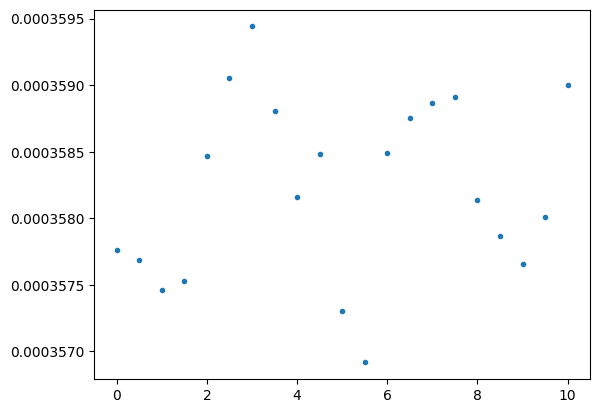

In [21]:
ID = 16
data = load_by_id(ID).get_parameter_data()
power90 = data['power90']['power90']
times = data['times']['times']

plt.plot(times, power90, '.')

In [31]:
from ipywidgets import interact, IntSlider
min_id = 16
max_id = 159

voltages = np.arange(0, 7.05, 0.05)

def plot_data(ID):
    data = load_by_id(ID).get_parameter_data()
    power90 = data['power90']['power90']
    times = data['times']['times']

    plt.title(f'ID {ID}')
    plt.plot(times, power90, '.')
    plt.xlabel('Time (s)')
    plt.ylabel('Power at 10% port after Attenuator (W)')
    plt.show()

interact(plot_data, ID=IntSlider(min=min_id, max=max_id, step=1, value=min_id,
                                  continuous_update=False));

interactive(children=(IntSlider(value=16, continuous_update=False, description='ID', max=159, min=16), Output(…

ID 100 ~1uW, lowest power according to spec sheet. 4.25V Attenuator.



In [32]:
from ipywidgets import interact, IntSlider
min_id = 16
max_id = 159

voltages = np.arange(0, 7.05, 0.05)

def plot_data(ID):
    data = load_by_id(ID).get_parameter_data()
    power90 = data['power90']['power90']
    attenuation = 10*np.log10((params.bs10/params.bs90*params.power90_base)/power90)
    times = data['times']['times']

    plt.title(f'ID {ID}')
    plt.plot(times, attenuation, '.')
    plt.ylabel('Attenuation dB')
    plt.xlabel('Time (s)')
    plt.show()

interact(plot_data, ID=IntSlider(min=min_id, max=max_id, step=1, value=min_id,
                                  continuous_update=False));

interactive(children=(IntSlider(value=16, continuous_update=False, description='ID', max=159, min=16), Output(…

4.45V is id 104

In [2]:
# meas = Measurement()
# meas.register_custom_parameter("ID_range", label="")
# meas.register_custom_parameter("v_attenuator", label="V")
# meas.register_custom_parameter("avg_attenuation", label="W")
# meas.register_custom_parameter("avg_power90", label="W")
# meas.register_custom_parameter("avg_power10", label="W")

# ID_range = np.arange(16, 157)
# v_range = np.arange(0, 7.05, 0.05)

# with meas.run() as datasaver: 
#     print(datasaver.run_id)
    
#     datasaver.dataset.add_metadata("attenuator_name", params.att_blue_name)
#     for i, ID in enumerate(ID_range): 
    
#         data = load_by_id(ID).get_parameter_data()
#         avg_attenuation = np.average(data['attenuation']['attenuation'])
#         avg_power90 = np.average(data['power90']['power90'])
#         avg_power10 = np.average(data['power10']['power10'])
        
#         datasaver.add_result(("ID_range", ID), 
#                              ("v_attenuator", v_range[i]),
#                              ("avg_attenuation", avg_attenuation),
#                             ("avg_power10", avg_power10),
#                             ("avg_power90", avg_power90)
#                             )
                                 

Starting experimental run with id: 160. 
160


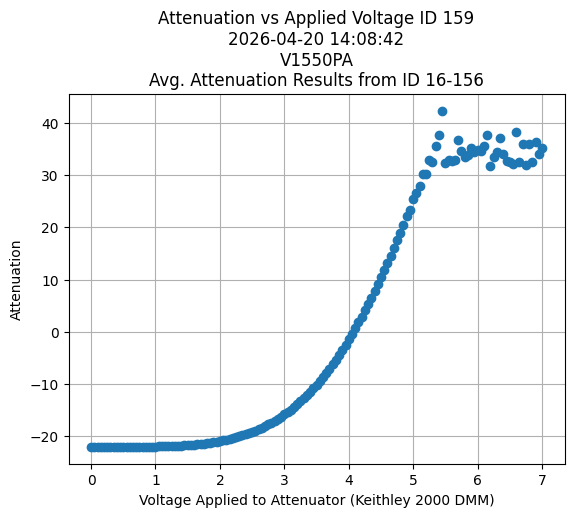

In [16]:
ID = params.att_blue_calibration_avg_id
data = load_by_id(ID).get_parameter_data()
timestamp = load_by_id(ID).run_timestamp()
avg_power90 = data['avg_power90']['avg_power90']/params.power90_base

attenuation = 10*np.log10((params.bs10/params.bs90*params.power90_base)/avg_power90) # avgpower90 contains average results 
v_attenuator = data['v_attenuator']['v_attenuator']
ID_range = data['ID_range']['ID_range']
plot_title = f'Attenuation vs Applied Voltage'
conditions = f'Avg. Attenuation Results from ID {int(ID_range[0])}-{int(ID_range[-1])}'
title_string = f'{plot_title} ID {ID}\n{timestamp}\n{att_name}\n{conditions}'

plt.plot(v_attenuator, attenuation, 'o')
plt.title(title_string)
plt.xlabel('Voltage Applied to Attenuator (Keithley 2000 DMM)')
# plt.ylabel('Average Power at 90% port over 10s (W)')
plt.ylabel('Attenuation') 
plt.grid()

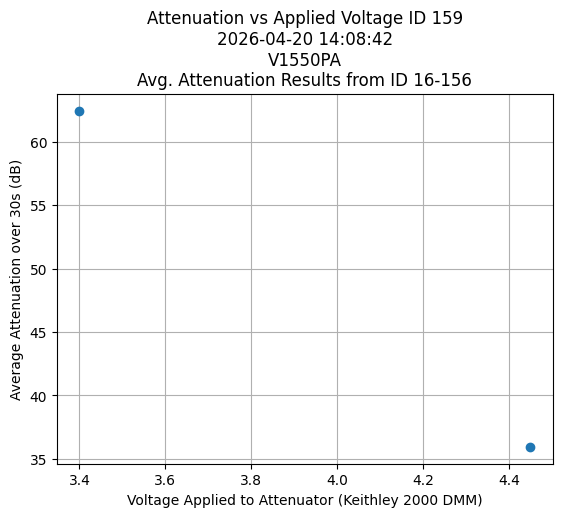

In [3]:
ID = params.att_blue_calibration_avg_id
data = load_by_id(ID).get_parameter_data()
timestamp = load_by_id(ID).run_timestamp()
att_name = load_by_id(ID).metadata['attenuator_name']
avg_attenuation = data['avg_attenuation']['avg_attenuation']
v_attenuator = data['v_attenuator']['v_attenuator']
ID_range = data['ID_range']['ID_range']
plot_title = f'Attenuation vs Applied Voltage'
conditions = f'Avg. Attenuation Results from ID {int(ID_range[0])}-{int(ID_range[-1])}'
title_string = f'{plot_title} ID {ID}\n{timestamp}\n{att_name}\n{conditions}'

plt.plot(v_attenuator, avg_attenuation, 'o')
plt.title(title_string)
plt.xlabel('Voltage Applied to Attenuator (Keithley 2000 DMM)')
plt.ylabel('Average Attenuation over 30s (dB)')
plt.grid()

Screw Attenuator 

In [ ]:
ID = 166
data = load_by_id(ID).get_parameter_data()
timestamp = load_by_id(ID).run_timestamp()
power = data['power']['power']/params.power90_base
times = data['times']['times']

attenuation = 10*np.log10((params.bs10/params.bs90*params.power90_base)/power) 

# plot_title = f'Attenuation vs Applied Voltage'
# conditions = f'Avg. Attenuation Results from ID {int(ID_range[0])}-{int(ID_range[-1])}'
# title_string = f'{plot_title} ID {ID}\n{timestamp}\n{att_name}\n{conditions}'

plt.plot(times, power, 'o')
plt.title(title_string)
plt.xlabel('Voltage Applied to Attenuator (Keithley 2000 DMM)')
# plt.ylabel('Average Power at 90% port over 10s (W)')
plt.ylabel('Attenuation') 
plt.grid()